# 02 — Basket interaction, with and without PM (R5)

> Run top to bottom.

`ADR-0011`'s Basket Scope Guard forbids any strategy but PM's own from *crossing* a
declared group boundary. It does **not** forbid another strategy from trading *within* the
same group. Here PM manages a WETH/USDC pair, and USDC shares a "stables" group with a
second stablecoin (USDT) that an independent, profit-seeking `XYCCompetitorStrategy`
trades — `GroupBoundaryGuard` allows this, since both tokens are in the same declared
group.

That competitor's trades change USDC/USDT's raw balances, which changes the **group's**
oracle-valued virtual balance (`Σ balance_j × oracle_price_j`, ADR-0003) — the number
PM's own curve actually prices against — without PM having traded at all. This notebook
asks: how much does PM's own presence and correction actually matter here?

Uses `aqua_sim.scenarios.basket_with_without_pm.build_world` directly, same rationale as
`01_pm_alone.ipynb`. Prices are synthetic-only (R2), same as every notebook in this suite.

In [1]:
import numpy as np

from aqua_sim.scenarios import basket_with_without_pm

N_STEPS = 2000
N_SEEDS = 10

te_with, te_without = [], []
for seed in range(N_SEEDS):
    world_with = basket_with_without_pm.build_world(with_pm=True, seed=seed)
    world_with.run(N_STEPS)
    te_with.append(np.mean(world_with.metrics.tracking_error_path))

    world_without = basket_with_without_pm.build_world(with_pm=False, seed=seed)
    world_without.run(N_STEPS)
    te_without.append(np.mean(world_without.metrics.tracking_error_path))

    print(f"seed {seed}: with PM = {te_with[-1]:.4%}, without PM = {te_without[-1]:.4%}")

te_with, te_without = np.array(te_with), np.array(te_without)
print(f"\nmean across seeds: with PM = {te_with.mean():.4%}, without PM = {te_without.mean():.4%}")

assert np.all(te_with < te_without), "PM presence should tighten tracking on every seed"
print("\nOK: PM's presence measurably tightens tracking on every seed, even though PM never touches USDC/USDT directly")

seed 0: with PM = 0.0271%, without PM = 4.5137%
seed 1: with PM = 0.0277%, without PM = 7.9572%
seed 2: with PM = 0.0297%, without PM = 10.2779%
seed 3: with PM = 0.0209%, without PM = 11.6069%
seed 4: with PM = 0.0239%, without PM = 4.1075%
seed 5: with PM = 0.0234%, without PM = 5.4765%
seed 6: with PM = 0.0239%, without PM = 5.0259%
seed 7: with PM = 0.0330%, without PM = 14.2091%
seed 8: with PM = 0.0282%, without PM = 6.4586%


seed 9: with PM = 0.0229%, without PM = 6.0718%

mean across seeds: with PM = 0.0261%, without PM = 7.5705%

OK: PM's presence measurably tightens tracking on every seed, even though PM never touches USDC/USDT directly


## Confirming the competitor never touches WETH directly

The competitor's own strategy is constructed against `(USDC, USDT)` only — it has no way
to reach WETH. Whatever tracking-error difference shows up above is entirely a
second-order effect through the shared group's virtual balance, not the competitor
touching PM's own token.

In [2]:
world = basket_with_without_pm.build_world(with_pm=False, seed=1)
initial_weth = world.token_balances["WETH"]
world.run(N_STEPS)

assert world.token_balances["WETH"] == initial_weth, "WETH balance should never move without PM registered"
print(f"WETH balance: {initial_weth} at start, {world.token_balances['WETH']} after {N_STEPS} steps -- unchanged")
print("\nOK: only USDC/USDT moved; WETH is untouched with no PM present")

WETH balance: 10.0 at start, 10.0 after 2000 steps -- unchanged

OK: only USDC/USDT moved; WETH is untouched with no PM present


## Visual

Tracking error over time, with vs. without PM, one representative seed.

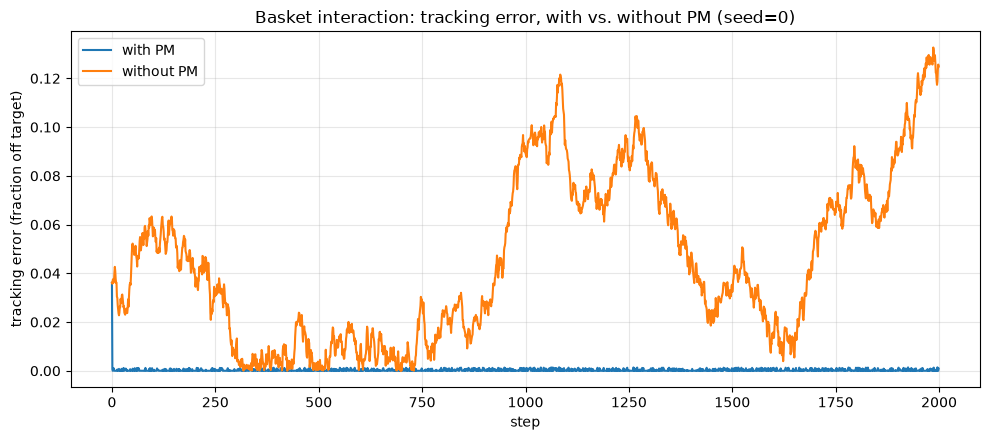

In [3]:
import matplotlib.pyplot as plt

world_with = basket_with_without_pm.build_world(with_pm=True, seed=0)
world_with.run(N_STEPS)
world_without = basket_with_without_pm.build_world(with_pm=False, seed=0)
world_without.run(N_STEPS)

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(world_with.metrics.tracking_error_path, label="with PM")
ax.plot(world_without.metrics.tracking_error_path, label="without PM")
ax.set_xlabel("step")
ax.set_ylabel("tracking error (fraction off target)")
ax.set_title("Basket interaction: tracking error, with vs. without PM (seed=0)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Visual: portfolio balance

Same two runs, this time plotting the actual portfolio balance over time — each group's
oracle-valued virtual balance (ADR-0003) and the total — not just the derived tracking-
error metric above.

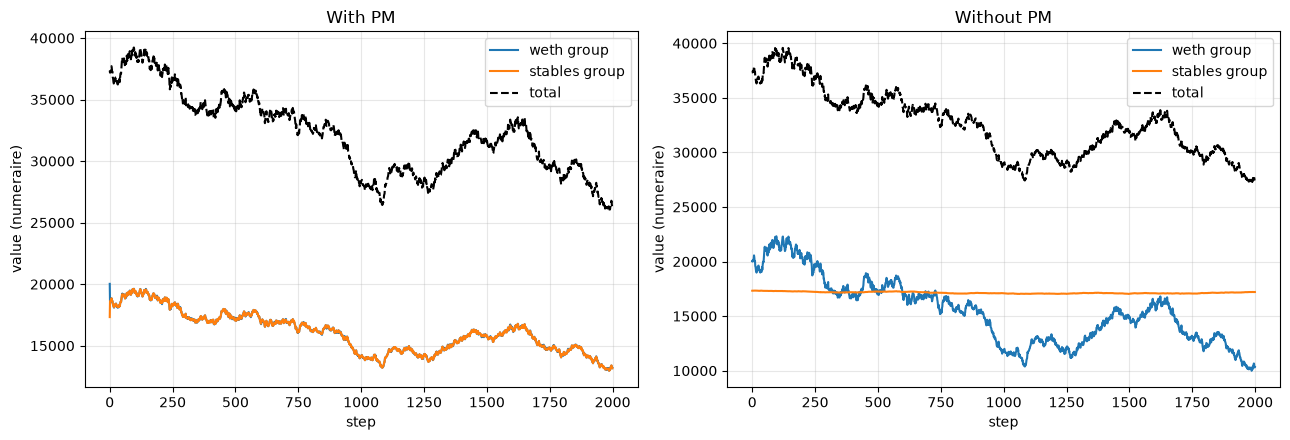

final total portfolio value: with PM = 26,369.63, without PM = 27,538.72


In [4]:
total_with = np.array(world_with.metrics.value_a_path) + np.array(world_with.metrics.value_b_path)
total_without = np.array(world_without.metrics.value_a_path) + np.array(world_without.metrics.value_b_path)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

ax1.plot(world_with.metrics.value_a_path, label="weth group")
ax1.plot(world_with.metrics.value_b_path, label="stables group")
ax1.plot(total_with, label="total", linestyle="--", color="black")
ax1.set_xlabel("step")
ax1.set_ylabel("value (numeraire)")
ax1.set_title("With PM")
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(world_without.metrics.value_a_path, label="weth group")
ax2.plot(world_without.metrics.value_b_path, label="stables group")
ax2.plot(total_without, label="total", linestyle="--", color="black")
ax2.set_xlabel("step")
ax2.set_ylabel("value (numeraire)")
ax2.set_title("Without PM")
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"final total portfolio value: with PM = {total_with[-1]:,.2f}, without PM = {total_without[-1]:,.2f}")

## Summary

PM's own presence measurably tightens tracking error and holds the WETH group's balance
close to target on every seed tested, even though PM never trades USDC/USDT directly —
the effect flows entirely through the shared group's oracle-valued virtual balance
(ADR-0003), which PM's curve reads and corrects against. Confirms R5 from
`thoughts/simulation-suite-v2-requirements.md`, generalized from the v1 package's one
hardcoded co-basket agent to `XYCCompetitorStrategy`, an independent, profit-seeking
`Strategy` implementation (R3/R4) that knows nothing about PM.

The competitor here is deliberately confined to `(USDC, USDT)` only — it's not that
anything stops it from reaching WETH, it just isn't built to try. `03_cross_basket_no_pm.ipynb`
removes that constraint entirely: no PM, and a competitor on every pair, including WETH.
`04_guard_enforcement.ipynb` covers the opposite case: PM present, and a strategy that
actively tries to cross into WETH and gets blocked every time.